Name: Lathika M
Roll No: 24BAD062
Scenario-1: CLUSTERING USING K-MEANS


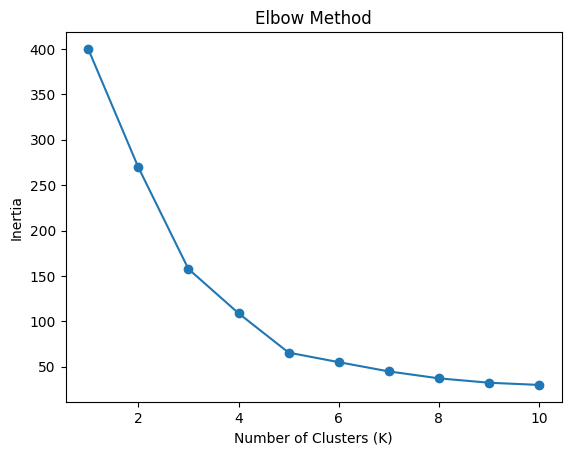

Silhouette Score: 0.5546571631111091
Cluster Centroids:
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


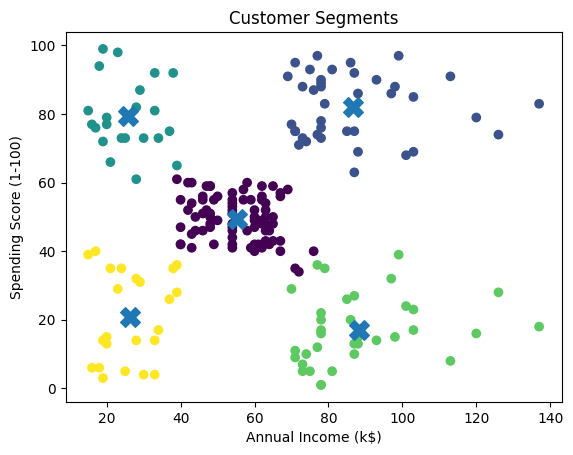

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [23]:
print("Name: Lathika M")
print("Roll No: 24BAD062")
print("Scenario-1: CLUSTERING USING K-MEANS")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

df = df.dropna()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
print("Cluster Centroids:\n", centroids)

plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=clusters)
plt.scatter(centroids[:,0], centroids[:,1], s=200, marker='X')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.show()

print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

Name: Lathika M
Roll No: 24BAD062
Scenario-2: CLUSTERING USING GMM
Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245
Cluster Probabilities (first 5 rows):
 [[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


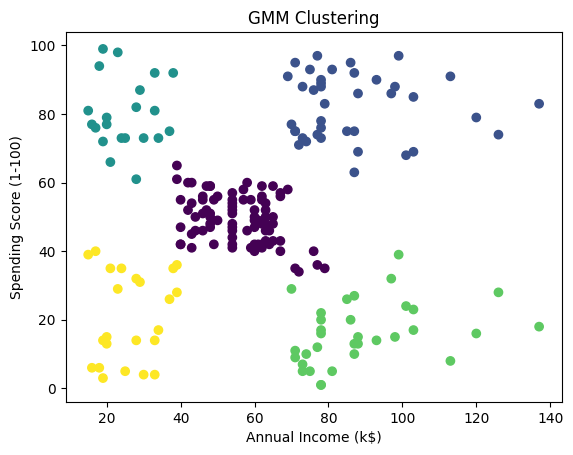

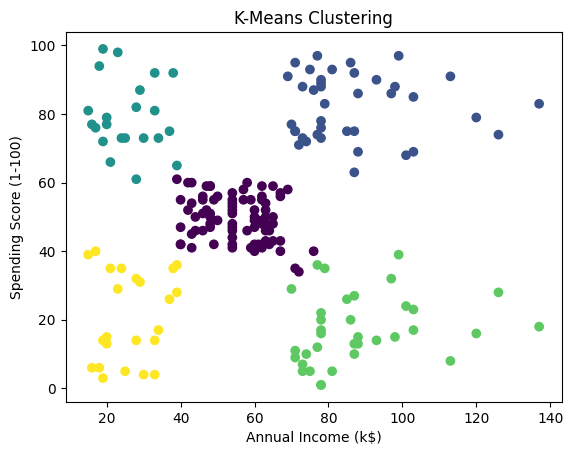

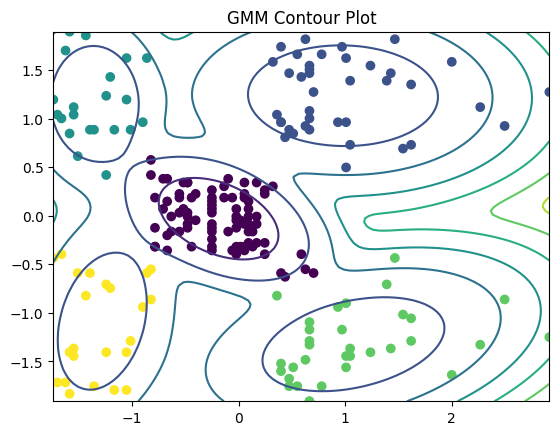

             Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                            
0                     55.642857               49.369048
1                     86.538462               82.128205
2                     25.095238               80.047619
3                     88.818182               16.000000
4                     26.304348               20.913043


In [25]:
print("Name: Lathika M")
print("Roll No: 24BAD062")
print("Scenario-2: CLUSTERING USING GMM")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

df = df.dropna()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

probs = gmm.predict_proba(X_scaled)
clusters = gmm.predict(X_scaled)

df['GMM_Cluster'] = clusters

log_likelihood = gmm.score(X_scaled)
aic = gmm.aic(X_scaled)
bic = gmm.bic(X_scaled)
sil_score = silhouette_score(X_scaled, clusters)

print("Log-Likelihood:", log_likelihood)
print("AIC:", aic)
print("BIC:", bic)
print("Silhouette Score:", sil_score)

print("Cluster Probabilities (first 5 rows):\n", probs[:5])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
k_clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = k_clusters

plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=clusters)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('GMM Clustering')
plt.show()

plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=k_clusters)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering')
plt.show()

x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)
grid = np.array([X_grid.ravel(), Y_grid.ravel()]).T

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title('GMM Contour Plot')
plt.show()

print(df.groupby('GMM_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())